# SLAKE — Surface EDA

**Goal:** understand the dataset before model/XAI decisions.

We focus on:
- parent task and task dimensions
- image vs QA structure
- modality and brain subset
- labels / answer types / language
- knowledge information
- split leakage
- research implications

This notebook uses the Hugging Face tabular representation and does **not** download/scan all image pixels.


## 1. Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset

from huggingface_hub import hf_hub_download
import zipfile
import io
import json
from PIL import Image

## 2. Load dataset

In [2]:
ds = load_dataset("BoKelvin/SLAKE")

print(ds)
for split in ds:
    print(f"{split}: {len(ds[split]):,} rows")


README.md:   0%|          | 0.00/568 [00:00<?, ?B/s]

train.json:   0%|          | 0.00/2.96M [00:00<?, ?B/s]

validation.json:   0%|          | 0.00/639k [00:00<?, ?B/s]

test.json:   0%|          | 0.00/636k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/9835 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2099 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2094 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['img_name', 'location', 'answer', 'modality', 'base_type', 'answer_type', 'question', 'qid', 'content_type', 'triple', 'img_id', 'q_lang'],
        num_rows: 9835
    })
    validation: Dataset({
        features: ['img_name', 'location', 'answer', 'modality', 'base_type', 'answer_type', 'question', 'qid', 'content_type', 'triple', 'img_id', 'q_lang'],
        num_rows: 2099
    })
    test: Dataset({
        features: ['img_name', 'location', 'answer', 'modality', 'base_type', 'answer_type', 'question', 'qid', 'content_type', 'triple', 'img_id', 'q_lang'],
        num_rows: 2094
    })
})
train: 9,835 rows
validation: 2,099 rows
test: 2,094 rows


## 3. Schema + one sample

In [3]:
train = ds["train"]

print("Columns:")
print(train.column_names)

print("\nFeatures:")
print(train.features)

print("\nOne sample:")
for k, v in train[0].items():
    print(f"{k}: {v}")


Columns:
['img_name', 'location', 'answer', 'modality', 'base_type', 'answer_type', 'question', 'qid', 'content_type', 'triple', 'img_id', 'q_lang']

Features:
{'img_name': Value('string'), 'location': Value('string'), 'answer': Value('string'), 'modality': Value('string'), 'base_type': Value('string'), 'answer_type': Value('string'), 'question': Value('string'), 'qid': Value('int64'), 'content_type': Value('string'), 'triple': List(Value('string')), 'img_id': Value('int64'), 'q_lang': Value('string')}

One sample:
img_name: xmlab1/source.jpg
location: Abdomen
answer: MRI
modality: MRI
base_type: vqa
answer_type: OPEN
question: What modality is used to take this image?
qid: 0
content_type: Modality
triple: ['vhead', '_', '_']
img_id: 1
q_lang: en


## 4. Build one table for lightweight EDA

A **row is one QA pair**. An `img_id` can appear in multiple rows because one image has multiple questions.


In [4]:
all_df = pd.concat(
    [ds[split].to_pandas().assign(split=split) for split in ds],
    ignore_index=True
)

print(f"Total QA rows: {len(all_df):,}")
print(f"Unique images: {all_df['img_id'].nunique():,}")
print(f"Unique QA IDs: {all_df['qid'].nunique():,}")


Total QA rows: 14,028
Unique images: 642
Unique QA IDs: 14,028


## 5. Parent task and task dimensions

For this dataset, the parent task is **Medical Visual Question Answering (Med-VQA)**.

The fields below describe different task dimensions rather than independent datasets.


In [5]:
for col in ["base_type", "content_type", "answer_type", "q_lang"]:
    print(f"\n--- {col} ---")
    print(all_df[col].value_counts(dropna=False))



--- base_type ---
base_type
vqa     12288
kvqa     1740
Name: count, dtype: int64

--- content_type ---
content_type
Organ          3560
Position       2426
Abnormality    1995
KG             1740
Modality       1522
Size            892
Plane           740
Quantity        635
Color           397
Shape           121
Name: count, dtype: int64

--- answer_type ---
answer_type
OPEN      8467
CLOSED    5561
Name: count, dtype: int64

--- q_lang ---
q_lang
en    7033
zh    6995
Name: count, dtype: int64


## 6. Modality and anatomical location

In [6]:
print("QA rows by modality:")
display(all_df["modality"].value_counts(dropna=False).rename("qa_count").to_frame())

print("\nQA rows by location:")
display(all_df["location"].value_counts(dropna=False).rename("qa_count").to_frame())

print("\nUnique images by modality:")
display(
    all_df[["img_id", "modality"]]
    .drop_duplicates("img_id")["modality"]
    .value_counts(dropna=False)
    .rename("image_count")
    .to_frame()
)


QA rows by modality:


,qa_count
modality,
CT,6639
X-Ray,4214
MRI,3175



QA rows by location:


,qa_count
location,
Lung,5001
Abdomen,4247
Brain_Tissue,2059
Brain,682
Pelvic Cavity,591
Neck,416
Brain_Face,407
Chest_lung,362
Chest_heart,199



Unique images by modality:


,image_count
modality,
CT,282
MRI,181
X-Ray,179


## 7. Brain subset

For this project, treat these three locations as the **brain-related subset**:

`Brain`, `Brain_Face`, `Brain_Tissue`.


In [7]:
BRAIN_LOCATIONS = ["Brain", "Brain_Face", "Brain_Tissue"]

brain_df = all_df[
    all_df["location"].isin(BRAIN_LOCATIONS)
].copy()

print(f"Brain-related QA rows: {len(brain_df):,}")
print(f"Brain-related unique images: {brain_df['img_id'].nunique():,}")

print("\nBrain location:")
display(
    brain_df["location"]
    .value_counts()
    .rename("qa_count")
    .to_frame()
)

print("\nBrain modality:")
display(
    brain_df["modality"]
    .value_counts()
    .rename("qa_count")
    .to_frame()
)


Brain-related QA rows: 3,148
Brain-related unique images: 165

Brain location:


,qa_count
location,
Brain_Tissue,2059
Brain,682
Brain_Face,407



Brain modality:


,qa_count
modality,
MRI,2464
CT,684


## 8. Brain task distribution

In [8]:
print("Question/content types:")
display(
    brain_df["content_type"]
    .value_counts()
    .rename("qa_count")
    .to_frame()
)

print("\nAnswer types:")
display(
    brain_df["answer_type"]
    .value_counts()
    .rename("qa_count")
    .to_frame()
)

print("\nQuestion languages:")
display(
    brain_df["q_lang"]
    .value_counts()
    .rename("qa_count")
    .to_frame()
)


Question/content types:


,qa_count
content_type,
Modality,610
Position,607
Organ,553
KG,367
Abnormality,358
Plane,252
Quantity,130
Color,129
Size,124



Answer types:


,qa_count
answer_type,
OPEN,2001
CLOSED,1147



Question languages:


,qa_count
q_lang,
en,1580
zh,1568


## 9. QA density per image

This tells us how much language supervision is attached to each image.


count    165.000000
mean      19.078788
std        4.043947
min       12.000000
25%       17.000000
50%       18.000000
75%       19.000000
max       32.000000
dtype: float64


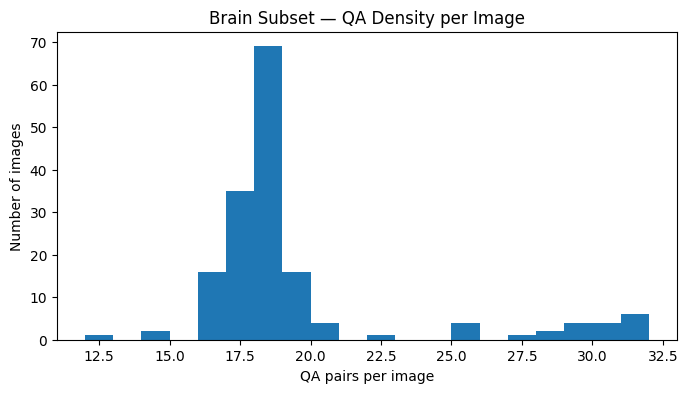

In [9]:
qa_per_image = brain_df.groupby("img_id").size()

print(qa_per_image.describe())

plt.figure(figsize=(8, 4))
plt.hist(qa_per_image, bins=20)
plt.xlabel("QA pairs per image")
plt.ylabel("Number of images")
plt.title("Brain Subset — QA Density per Image")
plt.show()


## 10. Inspect the actual medical language

In [10]:
display(
    brain_df[
        [
            "img_id",
            "img_name",
            "modality",
            "content_type",
            "answer_type",
            "q_lang",
            "question",
            "answer"
        ]
    ].sample(min(20, len(brain_df)), random_state=42)
)


,img_id,img_name,modality,content_type,answer_type,q_lang,question,answer
13743,44,xmlab44/source.jpg,MRI,Abnormality,OPEN,zh,图片中包含哪些疾病?,脑水肿
4547,62,xmlab62/source.jpg,MRI,Abnormality,OPEN,en,What diseases are included in the picture?,"Brain Tumor, Brain Edema"
8131,442,xmlab442/source.jpg,MRI,Plane,OPEN,zh,这个图像属于哪一个扫描平面?,横断面
7844,404,xmlab404/source.jpg,CT,Size,OPEN,zh,图片中最大的器官是什么?,大脑
13774,452,xmlab452/source.jpg,MRI,Plane,CLOSED,zh,这是矢状面吗?,不是
10682,518,xmlab518/source.jpg,MRI,Organ,OPEN,en,Which organ system is imaged?,Head
8448,488,xmlab488/source.jpg,MRI,Position,OPEN,zh,图中脑哪个半球是正常的?,左半球
7850,405,xmlab405/source.jpg,CT,Modality,CLOSED,zh,"这张图像显示的是哪种类型的成像,核磁共振、CT还是X光?",CT
11715,51,xmlab51/source.jpg,MRI,Organ,OPEN,zh,图片主要器官是什么?,大脑
8712,53,xmlab53/source.jpg,MRI,Modality,OPEN,zh,这张MRI图片用的什么加权方式?,T2


## 11. Knowledge-based QA

`KG` is one of the task dimensions. `triple` contains the associated knowledge representation when provided.


In [11]:
kg_df = brain_df[brain_df["content_type"] == "KG"].copy()

print(f"Brain KG QA rows: {len(kg_df):,}")

if len(kg_df):
    display(kg_df[["question", "answer", "triple"]].head(10))

print("\nNon-empty triples:")
print(brain_df["triple"].notna().sum())


Brain KG QA rows: 367


,question,answer,triple
2848,What is the function of the tissue on the left...,"Participate in hearing, speech and memory","[vhead, function, ktail]"
2849,Which organs/organ in the picture belong to se...,Eyes,"[vhead, belong to, sensory organs]"
2850,Does the picture contain the organ which has t...,No,"[vhead, effect, secrete enzymes]"
2851,Does the picture contain the organ that could ...,No,"[vhead, be used for, breathe]"
2864,What is the function of the tissue in the cent...,Control heartbeat and breathing,"[vhead, function, ktail]"
2865,Which organs/organ in the picture belong to se...,Eyes,"[vhead, belong to, sensory organs]"
2866,Does the picture contain the organ which has t...,No,"[vhead, effect, adjust water and osmotic press..."
2867,Does the picture contain the organ which has t...,No,"[vhead, effect, digest food]"
2880,What is the function of the tissue in the cent...,Control heartbeat and breathing,"[vhead, function, ktail]"
2881,Which organs/organ in the picture belong to se...,Eyes,"[vhead, belong to, sensory organs]"



Non-empty triples:
3148


## 12. Image-level split leakage check

Because an image can have many QA rows, the split check must be done with `img_id`, not row counts.


In [12]:
split_image_ids = {
    split: set(ds[split]["img_id"])
    for split in ds
}

for a, b in [
    ("train", "validation"),
    ("train", "test"),
    ("validation", "test")
]:
    overlap = len(split_image_ids[a] & split_image_ids[b])
    print(f"{a} ∩ {b}: {overlap} images")


train ∩ validation: 130 images
train ∩ test: 142 images
validation ∩ test: 26 images


## 13. Image files and spatial annotations

The Hugging Face table references images via `img_name`; image pixels are in the separate archive. The [official SLAKE release](https://www.med-vqa.com/slake/) documents semantic masks and bounding boxes. The cells below inspect only a small sample from that archive.

In [ ]:


# Requires internet access in the notebook. The archive is ~212 MB; download once and reuse the cached file.
IMG_ZIP = hf_hub_download(
    repo_id="BoKelvin/SLAKE",
    filename="imgs.zip",
    repo_type="dataset",
)

with zipfile.ZipFile(IMG_ZIP) as z:
    names = z.namelist()

print("Archive:", IMG_ZIP)
print("Files in archive:", len(names))
print("First 20 entries:")
for name in names[:20]:
    print(name)


imgs.zip: reconstructing file:   0%|          |  0.00B /  212MB            

imgs.zip: downloading bytes:           |  0.00B            

Archive: /root/.cache/huggingface/hub/datasets--BoKelvin--SLAKE/snapshots/a9083ce6c34ac3ffb17671a605962924d8a8f9e9/imgs.zip
Files in archive: 3235
First 20 entries:
imgs/
__MACOSX/._imgs
imgs/xmlab29/
imgs/xmlab198/
imgs/xmlab508/
imgs/xmlab395/
imgs/xmlab16/
imgs/xmlab537/
imgs/xmlab361/
imgs/xmlab153/
imgs/xmlab359/
imgs/xmlab154/
imgs/xmlab366/
imgs/xmlab530/
imgs/xmlab11/
imgs/xmlab392/
imgs/xmlab539/
imgs/xmlab18/
imgs/xmlab506/
imgs/xmlab162/


In [14]:
# Compare the HF table references with files in the image archive.
brain_images = (
    brain_df[["img_id", "img_name", "location", "modality"]]
    .drop_duplicates("img_id")
    .copy()
)

with zipfile.ZipFile(IMG_ZIP) as z:
    archive_set = set(z.namelist())

# img_name in the HF table is relative (e.g. "xmlab483/source.jpg"), but the
# actual paths inside imgs.zip are nested under an "imgs/" folder
# (e.g. "imgs/xmlab483/source.jpg"). Add the prefix before matching/opening.
brain_images["archive_path"] = "imgs/" + brain_images["img_name"]
brain_images["image_in_archive"] = brain_images["archive_path"].isin(archive_set)

print("Brain images in table:", len(brain_images))
print("Image references found in archive:", int(brain_images["image_in_archive"].sum()))
display(brain_images.head(10))

assert brain_images["image_in_archive"].mean() > 0.9, (
    "Most img_name values did not match the archive - check the path prefix again "
    "(e.g. run `next(iter(archive_set))` to inspect one real entry)."
)


Brain images in table: 165
Image references found in archive: 165


,img_id,img_name,location,modality,archive_path,image_in_archive
2836,395,xmlab395/source.jpg,Brain_Tissue,CT,imgs/xmlab395/source.jpg,True
2852,396,xmlab396/source.jpg,Brain_Tissue,CT,imgs/xmlab396/source.jpg,True
2868,397,xmlab397/source.jpg,Brain_Tissue,CT,imgs/xmlab397/source.jpg,True
2884,398,xmlab398/source.jpg,Brain_Tissue,CT,imgs/xmlab398/source.jpg,True
2899,399,xmlab399/source.jpg,Brain_Tissue,CT,imgs/xmlab399/source.jpg,True
2924,400,xmlab400/source.jpg,Brain_Tissue,CT,imgs/xmlab400/source.jpg,True
2939,402,xmlab402/source.jpg,Brain_Tissue,CT,imgs/xmlab402/source.jpg,True
2954,403,xmlab403/source.jpg,Brain_Face,CT,imgs/xmlab403/source.jpg,True
2968,406,xmlab406/source.jpg,Brain_Face,CT,imgs/xmlab406/source.jpg,True
2980,409,xmlab409/source.jpg,Brain_Face,CT,imgs/xmlab409/source.jpg,True


### 13.1 Image shape / dtype on a small brain sample

We inspect a few unique brain images only. This is enough to establish the image representation for Surface EDA; full-image statistics can be a separate Deep EDA later.

In [15]:
sample_image_rows = brain_images.sample(min(5, len(brain_images)), random_state=42)
image_meta = []

with zipfile.ZipFile(IMG_ZIP) as z:
    for _, row in sample_image_rows.iterrows():
        with z.open(row["archive_path"]) as f:
            img = Image.open(f)
            image_meta.append({
                "img_id": row["img_id"],
                "location": row["location"],
                "modality": row["modality"],
                "img_name": row["img_name"],
                "format": img.format,
                "mode": img.mode,
                "width": img.width,
                "height": img.height,
            })

display(pd.DataFrame(image_meta))


,img_id,location,modality,img_name,format,mode,width,height
0,483,Brain_Tissue,MRI,xmlab483/source.jpg,JPEG,RGB,240,240
1,394,Brain_Tissue,CT,xmlab394/source.jpg,JPEG,RGB,512,512
2,471,Brain_Tissue,MRI,xmlab471/source.jpg,JPEG,RGB,240,240
3,485,Brain_Tissue,MRI,xmlab485/source.jpg,JPEG,RGB,240,240
4,56,Brain,MRI,xmlab56/source.jpg,JPEG,RGB,240,240


### 13.2 Semantic masks and bounding boxes

Check whether `mask.png`, `detection.json`, and `question.json` exist for the sampled brain images. These sample checks do not establish annotation availability across every image. [Official source](https://www.med-vqa.com/slake/).

In [16]:
annotation_rows = []

with zipfile.ZipFile(IMG_ZIP) as z:
    for _, row in sample_image_rows.iterrows():
        folder = row["archive_path"].rsplit("/", 1)[0]
        mask_name = f"{folder}/mask.png"
        det_name = f"{folder}/detection.json"
        q_name = f"{folder}/question.json"

        record = {
            "img_id": row["img_id"],
            "mask_exists": mask_name in z.namelist(),
            "bbox_file_exists": det_name in z.namelist(),
            "question_file_exists": q_name in z.namelist(),
            "mask_unique_values": None,
            "bbox_objects": None,
        }

        if record["mask_exists"]:
            with z.open(mask_name) as f:
                mask_img = Image.open(f).convert("L")
                record["mask_unique_values"] = sorted(set(np.array(mask_img).ravel().tolist()))[:20]

        if record["bbox_file_exists"]:
            with z.open(det_name) as f:
                det = json.load(f)
                if isinstance(det, list):
                    record["bbox_objects"] = len(det)
                elif isinstance(det, dict):
                    record["bbox_objects"] = len(det.get("objects", det.get("annotations", []))) if isinstance(det.get("objects", det.get("annotations", [])), list) else None

        annotation_rows.append(record)

display(pd.DataFrame(annotation_rows))


,img_id,mask_exists,bbox_file_exists,question_file_exists,mask_unique_values,bbox_objects
0,483,True,True,True,"[0, 95, 140, 185]",3
1,394,True,True,True,"[0, 80, 90, 160, 170]",4
2,471,True,True,True,"[0, 95, 140]",2
3,485,True,True,True,"[0, 95, 140, 185]",3
4,56,True,True,True,"[0, 95, 140, 185]",3


In [17]:
# Semantic class mapping for mask IDs.
MASK_TXT = hf_hub_download(
    repo_id="BoKelvin/SLAKE",
    filename="mask.txt",
    repo_type="dataset",
)

print(open(MASK_TXT, encoding="utf-8").read())


mask.txt:   0%|          | 0.00/617 [00:00<?, ?B/s]

30:Left Humerus Head
35:Right Humerus Head
40:Larynx
45:Right Femoral Head
50:Left Femoral Head
55:Brain Stem
60:Duodenum
65:Tooth
70:Liver
75:Trachea
80:Left Eye
90:Right Eye
95:Brain Edema
105:Rectum
110:Esophagus
120:Left Ear
125:Bladder
130:Right Ear
135:Left Kidney
140:Brain Non-enhancing Tumor
145:Spinal Cord
150:Kidney Cancer
155:Right Kidney
160:Left Temporal Lobe
165:Stomach
170:Right Temporal Lobe
175:Liver Cancer
180:Heart
185:Brain Enhancing Tumor
200:Left Mandible
205:Small Bowel
210:Right Mandible
215:Left Lung
225:Right Lung
230:Spleen
235:Colon
240:Left Parotid
245:Lung Cancer
250:Right Parotid


### 13.3 One image + annotation visualization

Use one sample only to verify that the image, mask, and annotation files correspond spatially. This is a qualitative sanity check, not a quantitative XAI evaluation.

In [21]:
def load_image_and_mask(z, row):
    """Open a brain sample's source image and (optional) mask from the SLAKE image archive."""
    folder = row["archive_path"].rsplit("/", 1)[0]
    with z.open(row["archive_path"]) as f:
        source = Image.open(f).convert("RGB")

    mask_path = f"{folder}/mask.png"
    mask = None
    if mask_path in z.namelist():
        with z.open(mask_path) as f:
            mask = Image.open(f).convert("L")

    return source, mask


def plot_image_grid(image_rows, img_zip_path, cols=5, rows=4):
    """Plot a grid of brain samples with mask overlay, using ONE shared color scale
    (vmin/vmax) across all subplots so the same class ID always maps to the same
    color, instead of each subplot auto-scaling to its own min/max mask value."""
    n = min(len(image_rows), cols * rows)
    sample_rows = image_rows.head(n)

    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
    axes = np.array(axes).reshape(-1)

    with zipfile.ZipFile(img_zip_path) as z:
        # Pass 1: find the global max mask value across this grid's samples,
        # so the color scale is shared across subplots.
        global_vmax = 0
        masks_cache = {}
        for idx, row in sample_rows.iterrows():
            source, mask = load_image_and_mask(z, row)
            mask_arr = np.array(mask) if mask is not None else None
            masks_cache[idx] = (source, mask_arr)
            if mask_arr is not None:
                global_vmax = max(global_vmax, int(mask_arr.max()))

        # Pass 2: plot using the shared vmin/vmax
        for ax, (idx, row) in zip(axes, sample_rows.iterrows()):
            source, mask_arr = masks_cache[idx]
            ax.imshow(source)
            if mask_arr is not None:
                ax.imshow(
                    np.ma.masked_where(mask_arr == 0, mask_arr),
                    alpha=0.35,
                    cmap="viridis",
                    vmin=0,
                    vmax=global_vmax,
                )
                title = f"img_id={row['img_id']}"
            else:
                title = f"img_id={row['img_id']} (no mask)"
            ax.set_title(title, fontsize=8)
            ax.axis("off")

    for ax in axes[n:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()




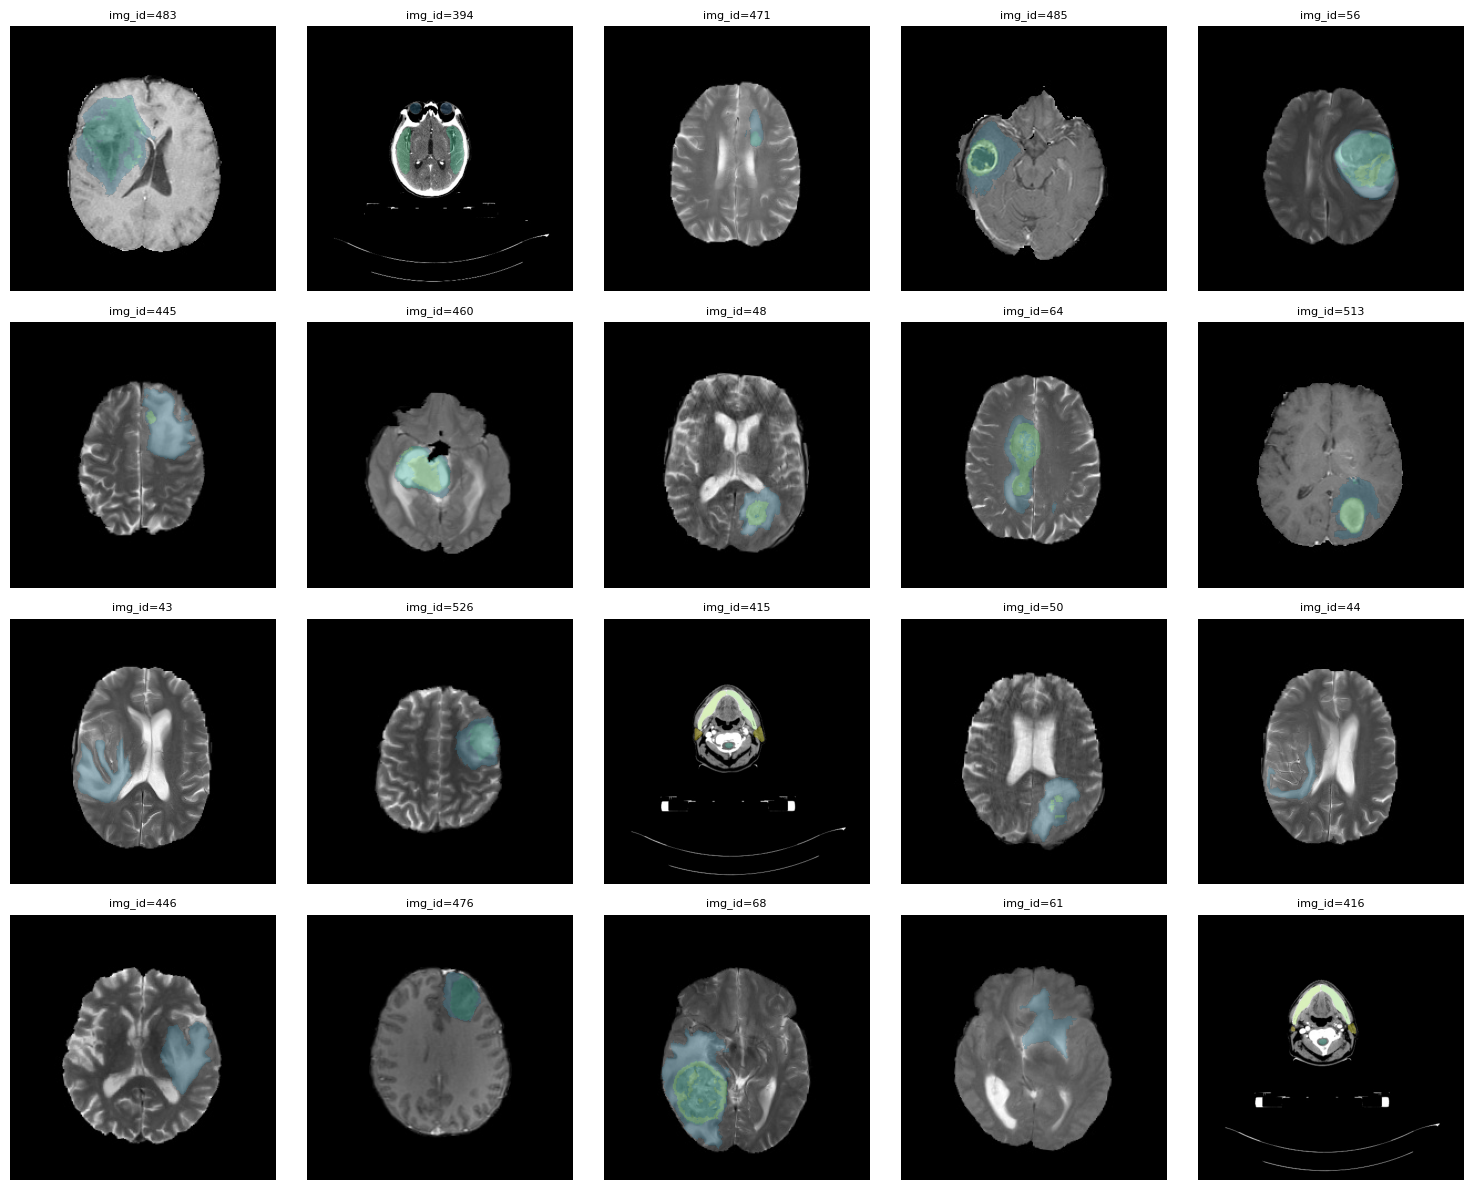

In [22]:
grid_sample_rows = brain_images.sample(min(20, len(brain_images)), random_state=42)
plot_image_grid(grid_sample_rows, IMG_ZIP, cols=5, rows=4)

## 14. Research summary

- **Task:** bilingual medical VQA, including open/closed answers and some knowledge-based questions; SLAKE is not limited to brain images or one pathology.
- **Full loaded set:** 14,028 QA rows over 642 unique images. One image can support multiple questions.
- **Brain-related subset in this notebook:** `Brain`, `Brain_Face`, and `Brain_Tissue` give **3,148 QA rows and 165 unique images**; the rows include 2,464 MRI and 684 CT examples.
- **Spatial annotations:** the sampled brain image folders contain semantic masks and bounding-box files. Some mask classes describe edema or tumor, but these are not universal lesion masks for all brain QA rows.
- **Split caution:** the provided QA splits share image IDs (130 train–validation, 142 train–test, 26 validation–test). Build image-disjoint splits before claiming image-level generalization.
- **Research role:** useful for image–question–answer grounding, with limited sampled spatial evidence; not a large brain-only VLM corpus. [Official source](https://www.med-vqa.com/slake/).
